# EO-LINCS project: Cube generation for Scientific Case Study (SCS) 2

## Forest recovery post disturbance

**Objective**: The SCS2 aims to estimate canopy height and above-ground biomass maps using deep learning methods based on remote sensing data. The canopy height and above-ground biomass maps are subsequently used to calculate recovery curves, which in turn can be used to estimate carbon budget.

**Outcomes**: New high-resolution height/biomass maps that are expected to enable the monitoring of biomass 
at finer scales, in particular the impact of fine scale forest disturbances due to management practices such as 
thinning and the impact of natural disturbances (insects attacks, droughts, fires and windthrown in regions of 
interest). Analysis of forest recovery depending on environmental factors (such as climate, soil composition 
and pH) and the nature and intensity of disturbance shall aid in the optimization of forest management 
considering potential increased future disturbances.

**Required Datasets**:
* [Global Age Mapping Integration (GAMI) dataset](https://gfzpublic.gfz-potsdam.de/pubman/faces/ViewItemOverviewPage.jsp?itemId=item_5029361)
* [European Forest Disturbance Atlas](https://zenodo.org/records/8389086)
* [Canopy height and biomass map for Europe](https://zenodo.org/records/8154445)  
* [Copernicus Tree cover density 2015](https://land.copernicus.eu/en/products/high-resolution-layer-tree-cover-density/tree-cover-density-2015)  
* [Copernicus Dominant Leaf Type 2015](https://land.copernicus.eu/en/products/high-resolution-layer-dominant-leaf-type/dominant-leaf-type-2015)  
* [Copernicus Forest Type 2015](https://land.copernicus.eu/en/products/high-resolution-layer-forest-type/forest-type-2015)

> **Note:** the last three datassets are excluded until the CLMS dataset migration is finalized.

-------------------------------------------------------------

The following notebook shows how the users can load data from various sources defined in `scs2_config.yml` using the `MultiSourceDataStore` tool.

#### **What You Can Do with This Notebook** 
- Load datasets from various sources as defined in the `scs2_config.yml`
- View the progress of each data request to the `MultiSourceDataStore`
- Quickly preview the datasets by downsampling and plotting them.

### **Requirements**  
Before you begin, ensure that all necessary dependencies are installed and that you have generated API token credentials for CLMS:  

- Install `xcube-multistore` via conda-forge by running: `conda install --channel conda-forge xcube-multistore`
- Generate CLMS API token credentials by following the [offical instructions](https://eea.github.io/clms-api-docs/authentication.html). Save the credentials in a file named `clms-credentials.json`, placing it in the same directory as this notebook. Note that the filename can be customized in the `scs2_config.yml` configuration file.

Once you have it installed, you are ready to proceed.

This Multistore mainly works with a file called `scs2_config.yml` which is at the same file level as this notebook.
To understand what goes into the schema, you can read more [here](https://xcube-dev.github.io/xcube-multistore/).

-------------------------------------------------------

Let's import the `MultiSourceDataStore`

In [1]:
from xcube_multistore import MultiSourceDataStore

You can find out how to fill out the config file by also using this super helpful function `get_config_schema()`. Run it and try expand the fields to learn more about the possible properties that the configuration file accepts along with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).

In [2]:
MultiSourceDataStore.get_config_schema()

To set up the config file, please refer to the notebook [setup_config.ipynb](../setup_config.ipynb) or the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/) in the documentation.

Now, we can initialize the `MultiSourceDataStore` by passing the path to the `scs2_config.yml` which currently is on the same level as this notebook. It shows, that for the user-defined dataset ID `clms` and `senf`, some data fusion of multiple data sources will be performed.

In [3]:
msds = MultiSourceDataStore("scs2_config.yml")

And we can display the overview of the configuration file for each dataset.

In [4]:
msds.display_config()

User-defined ID,Data Store ID,Data Store Params,Data ID,Open Data Params,Grid-Mapping,Format
senf,zenodo,root: 13333034,france/annual_disturbances_1985_2023_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
senf,zenodo,root: 13333034,france/disturbance_agent_1985_2023_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
senf,zenodo,root: 13333034,france/greatest_disturbance_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
senf,zenodo,root: 13333034,france/forest_mask_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
senf,zenodo,root: 13333034,france/disturbance_agent_aggregated_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
senf,zenodo,root: 13333034,france/latest_disturbance_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
senf,zenodo,root: 13333034,france/number_disturbances_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
senf,zenodo,root: 13333034,france/disturbance_probability_1985_2023_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
senf,zenodo,root: 13333034,france/disturbance_severity_1985_2023_france.tif,band_as_variable: False,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr
gami,s3,"root: dog.atlaseo-glm.eo-gridded-data; storage_options: {'anon': True, 'endpoint_url': 'https://s3.gfz-potsdam.de'}",collections/GAMI/GAMI_v2.1.zarr,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 4000",Zarr


We can display the selected bounding box as shown in the following cell.

In [5]:
msds.display_geolocations()

We can now generate the datacubes:

> **NOTE**: In the `scs2_config.yml` we are also using the `custom_processing` feature of this tool that allows us to run a function for processing each dataset separately. In this example, we have defined a module called `modify_dataset` that does some custom processing which takes a `xarray.Dataset` argument as input and returns a new `xarray.Dataset` object. To read more about this `custom_processing` function, you can see more [here](https://xcube-dev.github.io/xcube-multistore/config/#custom_processing).

In [6]:
msds.generate()

Dataset identifier,Status,Message,Exception
france.zip,COMPLETED,Already preloaded.,-


Dataset identifier,Status,Message,Exception
senf,COMPLETED,Dataset 'senf' finished: 0:24:48,-
gami,COMPLETED,Dataset 'gami' finished: 0:00:35,-
liu,COMPLETED,Dataset 'liu' finished: 0:17:30,-


We can now open the data using the xcube datastore framework API as usual. Note that the multi-source data store requires a data store called `storage`, which is configured in our `scs2_config.yml` under the `data_stores` section.

In [7]:
ds = msds.stores.storage.open_data("gami.zarr")
ds

<xarray.Dataset> Size: 6GB
Dimensions:      (members: 20, time: 2, latitude: 5199, longitude: 7000,
                  lat: 5199, lon: 7000)
Coordinates:
  * members      (members) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * time         (time) datetime64[ns] 16B 2010-01-01 2020-01-01
  * lat          (lat) float64 42kB 44.8 44.8 44.8 44.8 ... 43.5 43.5 43.5 43.5
  * lon          (lon) float64 56kB -1.25 -1.25 -1.249 ... 0.4994 0.4996 0.4999
    spatial_ref  int64 8B ...
Dimensions without coordinates: latitude, longitude
Data variables:
    forest_age   (members, time, latitude, longitude) float32 6GB dask.array<chunksize=(5, 2, 4000, 4000), meta=np.ndarray>
Attributes:
    _FillValue:          -9999
    contact:             Simon Besnard (GFZ Potsdam)
    created_by:          Simon Besnard
    creation_date:       2025-12-16 12:33
    crs:                 EPSG:4326
    institution:         Helmholtz Centre Potsdam – GFZ German Research Centr...
    product_name:        Global Age Mapping Integration (GAMI)
    spatial_resolution:  100 m
    title:               Global Age Mapping Integration (GAMI) v2.1
    version:             2.1

We can now select a variable for one timestep, downsample and plot it for a quick preview of the data

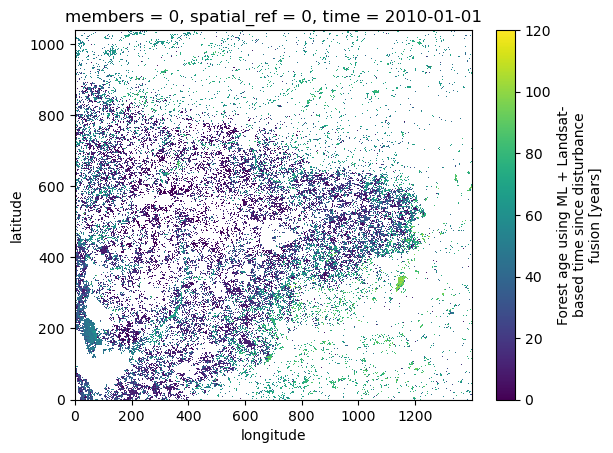

In [8]:
ds["forest_age"].isel(members=0, time=0)[::5, ::5].plot(vmin=0, vmax=120)

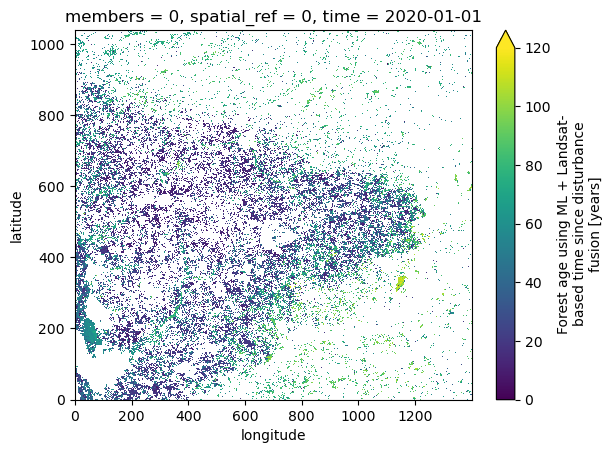

In [9]:
ds["forest_age"].isel(members=0, time=1)[::5, ::5].plot(vmin=0, vmax=120)

In [10]:
ds = msds.stores.storage.open_data("liu.zarr")
ds

<xarray.Dataset> Size: 874MB
Dimensions:        (lat: 5199, lon: 7000)
Coordinates:
  * lat            (lat) float64 42kB 44.8 44.8 44.8 44.8 ... 43.5 43.5 43.5
  * lon            (lon) float64 56kB -1.25 -1.25 -1.249 ... 0.4996 0.4999
    spatial_ref    int64 8B ...
Data variables:
    agb            (lat, lon) float64 291MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    canopy_cover   (lat, lon) float64 291MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    canopy_height  (lat, lon) float64 291MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>

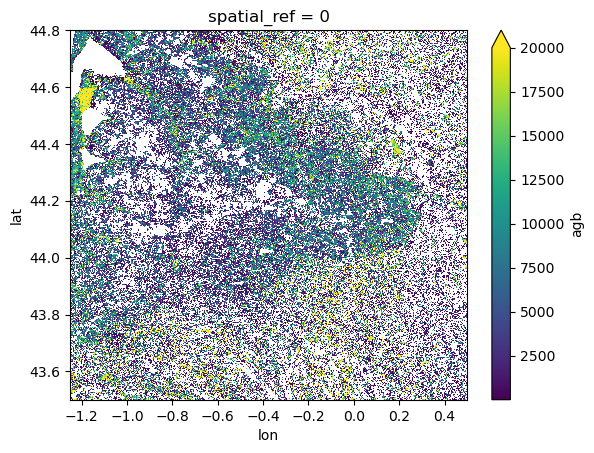

In [11]:
ds["agb"][::5, ::5].plot(vmax=20000)

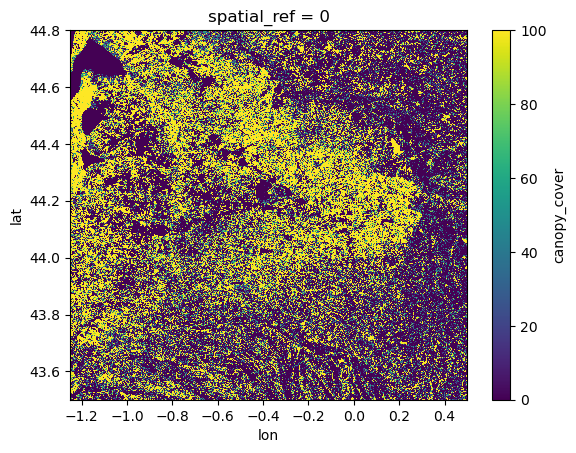

In [12]:
ds["canopy_cover"][::5, ::5].plot()

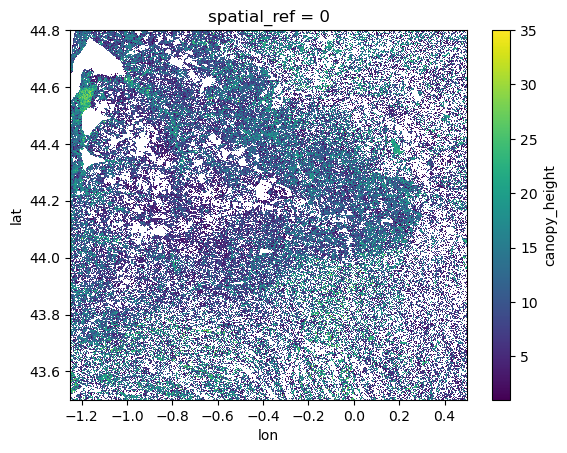

In [13]:
ds["canopy_height"][::5, ::5].plot()

In [14]:
ds = msds.stores.storage.open_data("senf.zarr")
ds

<xarray.Dataset> Size: 47GB
Dimensions:                       (time: 39, lat: 5199, lon: 7000)
Coordinates:
  * time                          (time) datetime64[ns] 312B 1985-01-01 ... 2...
  * lat                           (lat) float64 42kB 44.8 44.8 ... 43.5 43.5
  * lon                           (lon) float64 56kB -1.25 -1.25 ... 0.4999
    spatial_ref                   int64 8B ...
Data variables:
    annual_disturbances           (time, lat, lon) float64 11GB dask.array<chunksize=(1, 4000, 4000), meta=np.ndarray>
    disturbance_agent             (time, lat, lon) float64 11GB dask.array<chunksize=(1, 4000, 4000), meta=np.ndarray>
    disturbance_agent_aggregated  (lat, lon) float64 291MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    disturbance_probability       (time, lat, lon) float64 11GB dask.array<chunksize=(1, 4000, 4000), meta=np.ndarray>
    disturbance_severity          (time, lat, lon) float64 11GB dask.array<chunksize=(1, 4000, 4000), meta=np.ndarray>
    forest_mask                   (lat, lon) float64 291MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    greatest_disturbance          (lat, lon) float64 291MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    latest_disturbance            (lat, lon) float64 291MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>
    number_disturbances           (lat, lon) float64 291MB dask.array<chunksize=(4000, 4000), meta=np.ndarray>

In [18]:
ds.annual_disturbances.encoding

{'chunks': (1, 4000, 4000),
 'preferred_chunks': {'time': 1, 'lat': 4000, 'lon': 4000},
 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0),
 'filters': None,
 '_FillValue': np.uint8(255),
 'scale_factor': 1.0,
 'add_offset': 0.0,
 'dtype': dtype('uint8'),
 'coordinates': 'spatial_ref'}

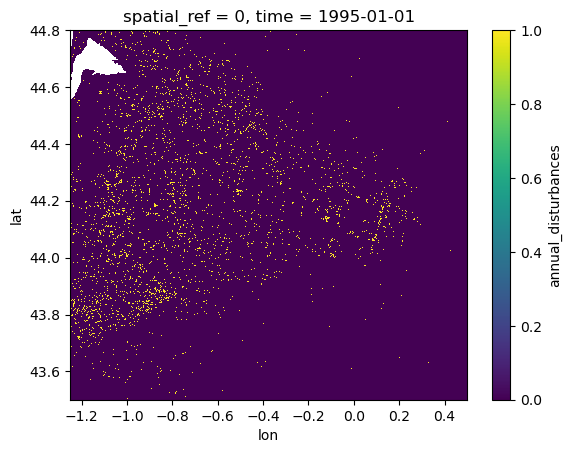

In [15]:
ds["annual_disturbances"].isel(time=10)[::5, ::5].plot()

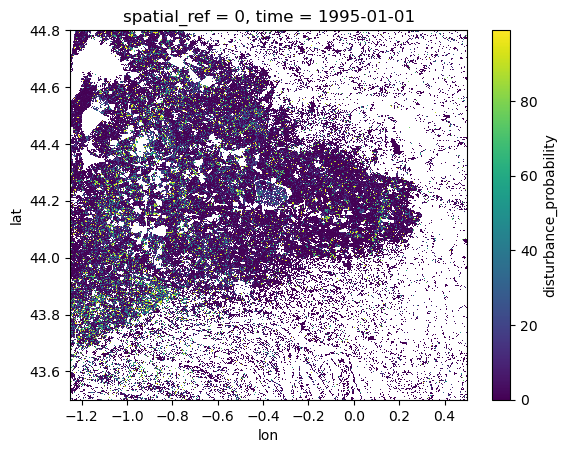

In [16]:
ds["disturbance_probability"].isel(time=10)[::5, ::5].plot()